In [1]:
import pandas as pd
ratings = pd.read_csv("../dataset/ml-1m/ratings.dat", sep="::", engine="python", header=None, names=["userId", "movieId", "rating", "timestamp"])

In [2]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
print(n_users)
print(n_movies)

6040
3706


In [3]:
observed_ratings = len(ratings)
print(observed_ratings)

1000209


In [4]:
possible_ratings = n_users * n_movies
print(possible_ratings)

22384240


In [5]:
density = observed_ratings/possible_ratings
print(density)
print(f"{density:.4%}")

0.044683625622312845
4.4684%


# Movie Popularity Distribution
`groupby("movieId")` looks at the ratings and group all the rows as movieId and `size` counts how many rows(ratings) are in each movies bucket and sorting the counts from the highest to lowest.

In [6]:
movie_counts = ratings.groupby("movieId").size()
movie_counts = movie_counts.sort_values(ascending=False)

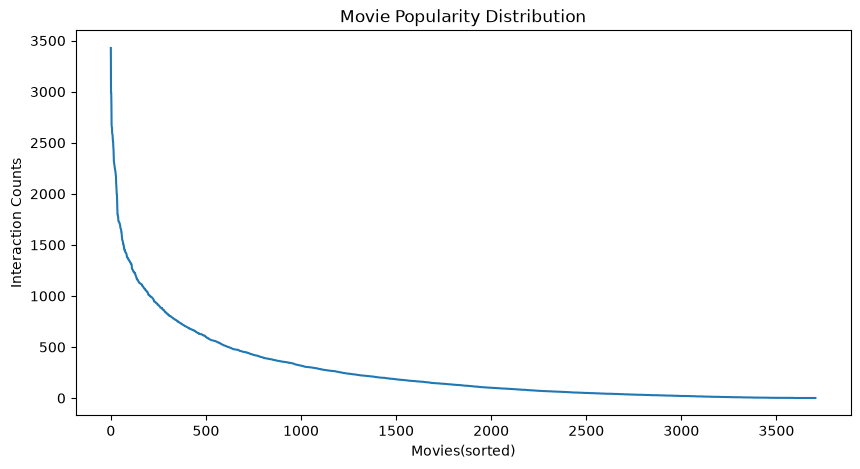

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(movie_counts.values)
plt.xlabel("Movies(sorted)")
plt.ylabel("Interaction Counts")
plt.title("Movie Popularity Distribution")
plt.show()

# User Bias
Are user inherently generous or strict?. This show the Average ratings per user.
suppose A rate 5 5 4 5 -> mean is 4.75
another B rate 2 2 3 1 -> mean is 2.0
for the same movie **Movie X** 
- A gives 4 and B gives 2
Without **normalization**:
model thinks: A likes more
but in reality:
A rates everything high.
B rates everything low.
hence $$r'_{ui} =r_{ui}​−μ_u$$ subtract user average.

In [8]:
user_mean = ratings.groupby("userId")["rating"].mean()

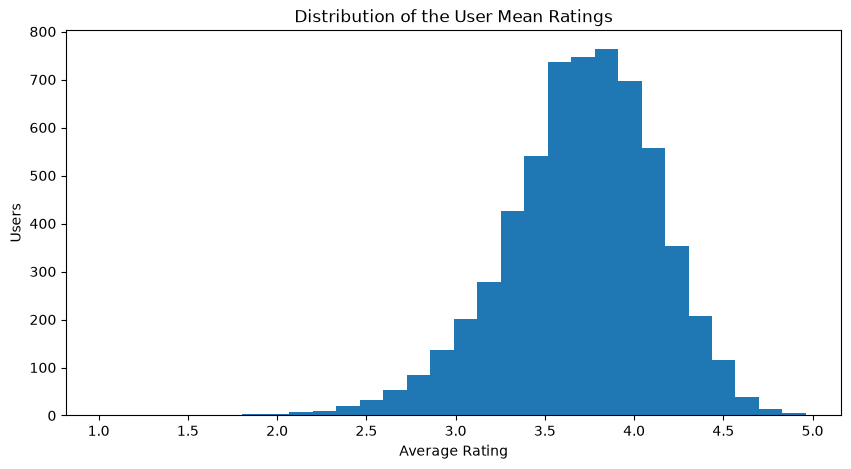

In [9]:
plt.figure(figsize=(10,5))
plt.hist(user_mean, bins=30)
plt.xlabel("Average Rating")
plt.ylabel("Users")
plt.title("Distribution of the User Mean Ratings")
plt.show()